In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
summary = pd.read_csv("summary_results.csv")

In [8]:
import matplotlib.pyplot as plt

def plot_accuracy_vs_latency(
    df,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(8, 6),
    marker_size=80,
    font_size=12,
    title=None,
    x_label="Latência média de inferência (ms)",
    y_label="Acurácia média",
    annotate=True,
    grid=True,
    save_path=None,
    dpi=300
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df[x_col],
        df[y_col],
        s=marker_size
    )

    if annotate:
        for _, row in df.iterrows():
            ax.annotate(
                row[label_col],
                (row[x_col], row[y_col]),
                fontsize=font_size - 2,
                xytext=(5, 5),
                textcoords="offset points"
            )

    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)

    if title:
        ax.set_title(title, fontsize=font_size + 2)

    if grid:
        ax.grid(True, linestyle="--", alpha=0.6)

    ax.tick_params(labelsize=font_size - 2)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


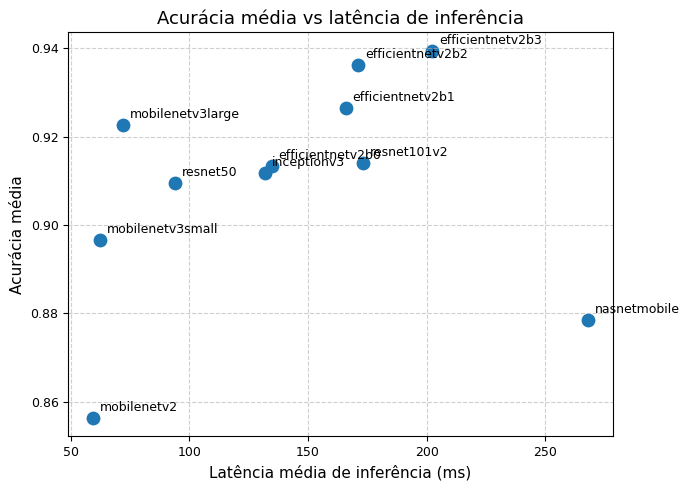

In [10]:
plot_accuracy_vs_latency(
    summary,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(7, 5),
    font_size=11,
    title="Acurácia média vs latência de inferência",
    save_path="accuracy_vs_latency.png"
)

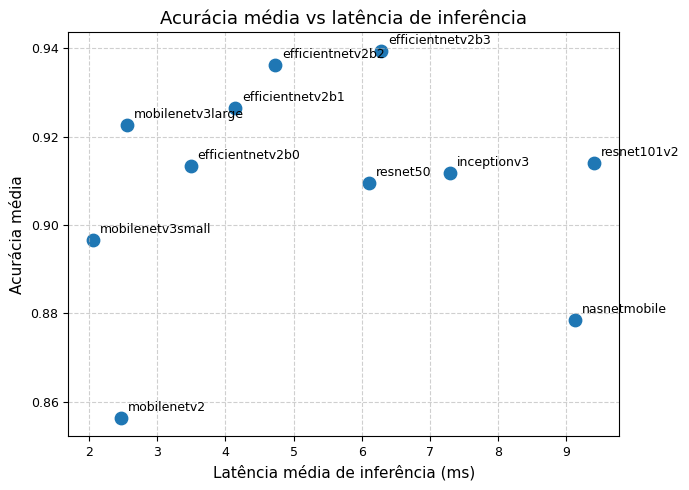

In [11]:
plot_accuracy_vs_latency(
    summary,
    x_col="Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(7, 5),
    font_size=11,
    title="Acurácia média vs latência de inferência",
    save_path="accuracy_vs_latency.png"
)

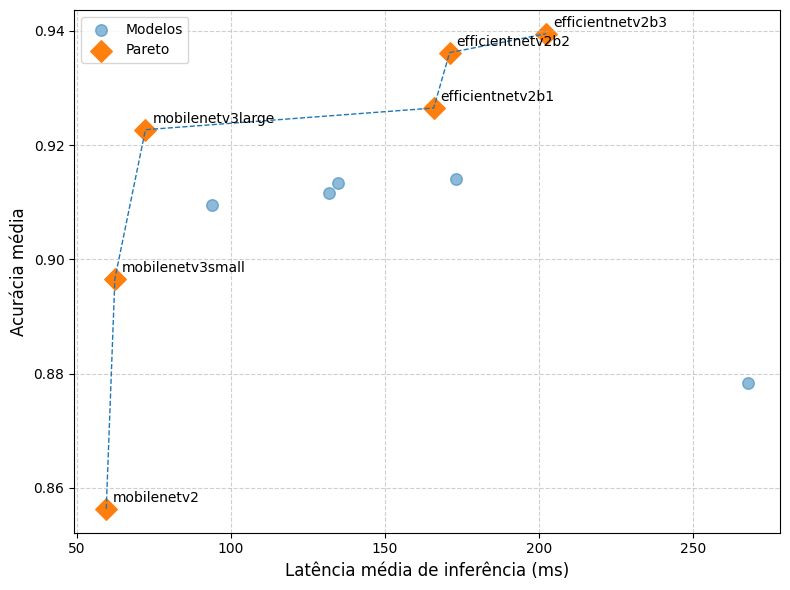

In [17]:
def pareto_frontier(df, x_col, y_col):
    """
    Minimiza x_col e maximiza y_col
    """
    df_sorted = df.sort_values(x_col)
    pareto_points = []
    best_y = -float("inf")

    for _, row in df_sorted.iterrows():
        if row[y_col] > best_y:
            pareto_points.append(row)
            best_y = row[y_col]

    return df_sorted.loc[[r.name for r in pareto_points]]


def plot_accuracy_vs_latency_pareto(
    df,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(8, 6),
    font_size=12,
    marker_size=70,
    pareto_marker_size=120,
    annotate=True,
    save_path=None,
    dpi=300
):
    pareto_df = pareto_frontier(df, x_col, y_col)

    fig, ax = plt.subplots(figsize=figsize)

    # Todos os modelos
    ax.scatter(
        df[x_col],
        df[y_col],
        s=marker_size,
        alpha=0.5,
        label="Modelos"
    )

    # Pareto frontier
    ax.scatter(
        pareto_df[x_col],
        pareto_df[y_col],
        s=pareto_marker_size,
        marker="D",
        label="Pareto"
    )

    # Linha da fronteira
    ax.plot(
        pareto_df[x_col],
        pareto_df[y_col],
        linestyle="--",
        linewidth=1
    )

    if annotate:
        for _, row in pareto_df.iterrows():
            ax.annotate(
                row[label_col],
                (row[x_col], row[y_col]),
                fontsize=font_size - 2,
                xytext=(5, 5),
                textcoords="offset points"
            )

    ax.set_xlabel("Latência média de inferência (ms)", fontsize=font_size)
    ax.set_ylabel("Acurácia média", fontsize=font_size)

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=font_size - 2)
    ax.tick_params(labelsize=font_size - 2)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    
    
plot_accuracy_vs_latency_pareto(
    summary,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    annotate=True,
    save_path="accuracy_latency_pareto.png"
)


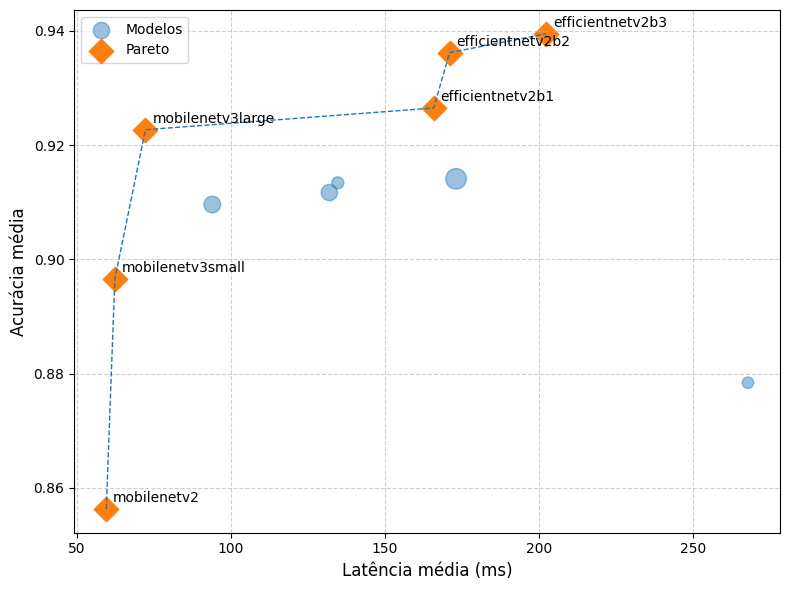

In [19]:
def pareto_frontier(df, x_col, y_col):
    d = df[[x_col, y_col]].dropna().sort_values(x_col)
    keep_idx = []
    best_y = -float("inf")
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            keep_idx.append(idx)
            best_y = row[y_col]
    return df.loc[keep_idx].sort_values(x_col)

def plot_pareto_bubble(
    df,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    size_col="Parâmetros (M)",
    label_col="Modelo",
    figsize=(8, 6),
    font_size=12,
    size_scale=220,
    alpha=0.45,
    annotate_pareto=True,
    save_path=None,
    dpi=300
):
    d = df[[x_col, y_col, size_col, label_col]].dropna().copy()
    p = pareto_frontier(d, x_col, y_col)

    # tamanhos
    s = d[size_col].to_numpy()
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-12)
    sizes = (0.25 + 0.75 * s_norm) * size_scale

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(d[x_col], d[y_col], s=sizes, alpha=alpha, label="Modelos")

    # Pareto (destaque)
    ax.scatter(p[x_col], p[y_col], s=size_scale*0.7, marker="D", label="Pareto")
    ax.plot(p[x_col], p[y_col], linestyle="--", linewidth=1)

    if annotate_pareto:
        for _, r in p.iterrows():
            ax.annotate(r[label_col], (r[x_col], r[y_col]),
                        fontsize=font_size-2, xytext=(5, 5),
                        textcoords="offset points")

    ax.set_xlabel("Latência média (ms)", fontsize=font_size)
    ax.set_ylabel("Acurácia média", fontsize=font_size)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=font_size-2)
    ax.tick_params(labelsize=font_size-2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


plot_pareto_bubble(summary, save_path="pareto_bubble.png")


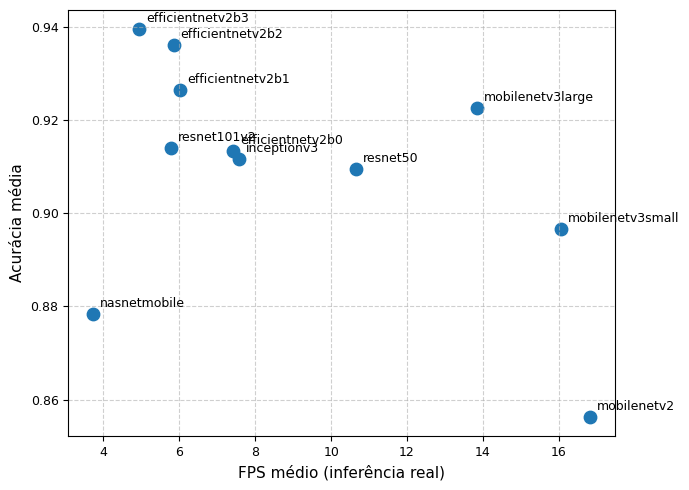

In [22]:
def plot_accuracy_vs_fps(
    df,
    x_col="[Real] FPS Média",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(8, 6),
    font_size=12,
    marker_size=80,
    annotate=True,
    save_path=None,
    dpi=300
):
    d = df[[x_col, y_col, label_col]].dropna().copy()

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(d[x_col], d[y_col], s=marker_size)

    if annotate:
        for _, r in d.iterrows():
            ax.annotate(r[label_col], (r[x_col], r[y_col]),
                        fontsize=font_size-2, xytext=(5, 5),
                        textcoords="offset points")

    ax.set_xlabel("FPS médio (inferência real)", fontsize=font_size)
    ax.set_ylabel("Acurácia média", fontsize=font_size)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(labelsize=font_size-2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    
plot_accuracy_vs_fps(
    summary,
    x_col="[Real] FPS Média",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(7, 5),
    font_size=11,
    save_path="accuracy_vs_fps.png"
)


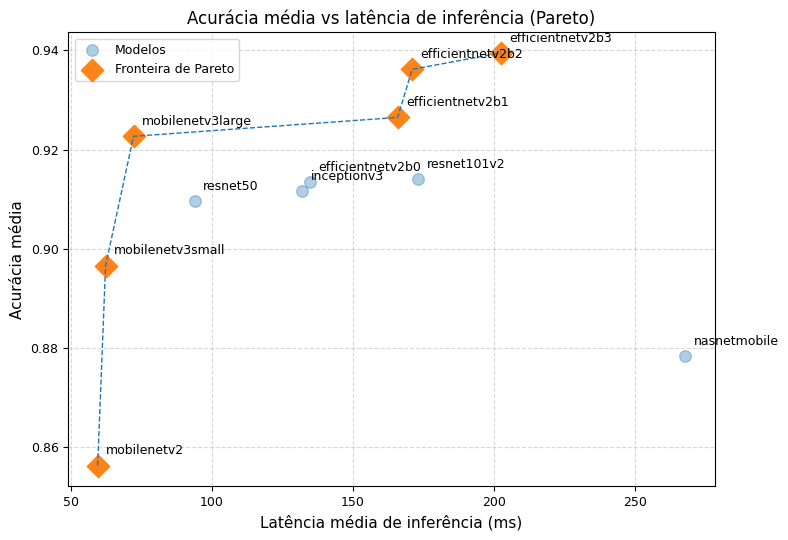

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pareto_frontier_indices_minx_maxy(df, x_col, y_col):
    """
    Retorna índices da fronteira de Pareto para:
      - minimizar x_col (latência)
      - maximizar y_col (acurácia)
    Critério: pontos não-dominados.
    """
    d = df[[x_col, y_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    pareto_idx = []
    best_y = -np.inf
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            pareto_idx.append(idx)
            best_y = row[y_col]
    return pareto_idx


def plot_accuracy_vs_latency_pareto(
    df,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(8.0, 5.5),
    font_size=11,
    marker_size=70,
    pareto_marker_size=130,
    alpha_other=0.35,
    alpha_pareto=0.95,
    annotate_all=True,
    annotate_only_pareto=False,   # se True, anota só Pareto
    text_offset=(6, 6),
    text_rotation=0,
    grid=True,
    title="Acurácia média vs latência de inferência (Pareto)",
    x_label="Latência média de inferência (ms)",
    y_label="Acurácia média",
    x_log=False,
    x_limits=None,               # ex.: (0, 20)
    y_limits=None,               # ex.: (0.80, 0.96)
    pareto_line=True,
    save_path=None,
    dpi=300
):
    # Copia e limpa
    d = df[[x_col, y_col, label_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    # Pareto
    pareto_idx = pareto_frontier_indices_minx_maxy(d, x_col, y_col)
    p = d.loc[pareto_idx].sort_values(x_col)

    fig, ax = plt.subplots(figsize=figsize)

    # Pontos gerais
    ax.scatter(
        d[x_col], d[y_col],
        s=marker_size,
        alpha=alpha_other,
        label="Modelos"
    )

    # Pontos Pareto (destaque)
    ax.scatter(
        p[x_col], p[y_col],
        s=pareto_marker_size,
        marker="D",
        alpha=alpha_pareto,
        label="Fronteira de Pareto"
    )

    # Linha Pareto (degrau ou tracejada)
    if pareto_line and len(p) >= 2:
        ax.plot(p[x_col], p[y_col], linestyle="--", linewidth=1)

    # Anotações
    def _annotate_rows(dd):
        for _, r in dd.iterrows():
            ax.annotate(
                str(r[label_col]),
                (r[x_col], r[y_col]),
                xytext=text_offset,
                textcoords="offset points",
                fontsize=font_size - 2,
                rotation=text_rotation,
                ha="left",
                va="bottom"
            )

    if annotate_only_pareto:
        _annotate_rows(p)
    elif annotate_all:
        _annotate_rows(d)

    # Eixos / labels
    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    if title:
        ax.set_title(title, fontsize=font_size + 1)

    # Escala log (opcional)
    if x_log:
        ax.set_xscale("log")

    # Limites (opcional)
    if x_limits is not None:
        ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    # Grid e legenda
    if grid:
        ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=font_size - 2)

    ax.tick_params(labelsize=font_size - 2)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


plot_accuracy_vs_latency_pareto(
     summary,
     x_col="[Real] Latência Média (ms)",
     y_col="Acurácia Média",
     label_col="Modelo",
     annotate_all=True,
     save_path="acc_vs_latency_pareto.png"
)


In [26]:
summary.columns

Index(['[Real] Latência Média (ms)', '[Real] FPS Média', 'Modelo',
       'Acurácia Média', 'Precisão Média', 'Recall Médio', 'F1 Médio',
       'weighted_precision', 'weighted_recall', 'weighted_f1', 'support_total',
       'Parâmetros (M)', 'GFLOPs', 'GMAC', 'Latência Média (ms)', 'FPS Média'],
      dtype='object')

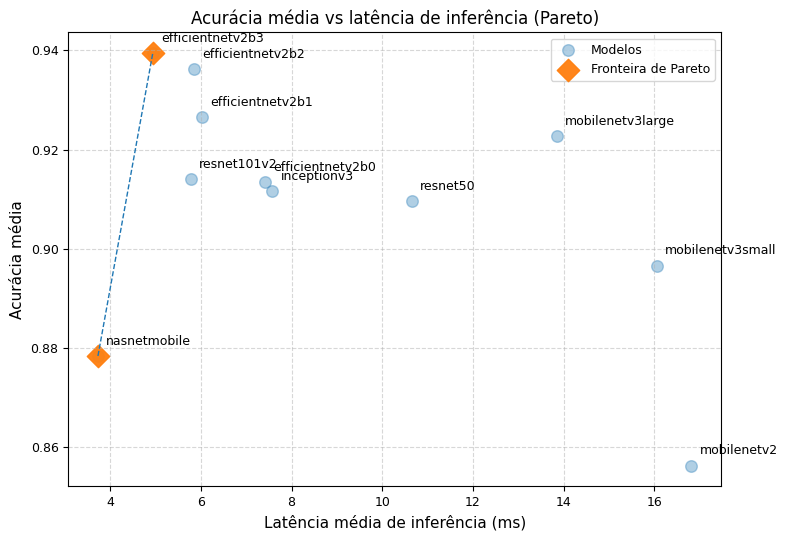

In [27]:
plot_accuracy_vs_latency_pareto(
     summary,
     x_col="[Real] FPS Média",
     y_col="Acurácia Média",
     label_col="Modelo",
     annotate_all=True,
     save_path="acc_vs_latency_pareto.png"
)

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def pareto_frontier_indices_minx_maxy(df, x_col, y_col):
    d = df[[x_col, y_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    pareto_idx = []
    best_y = -np.inf
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            pareto_idx.append(idx)
            best_y = row[y_col]
    return pareto_idx


def plot_metric_vs_accuracy_pareto(
    df,
    x_col,                               # ex.: "[Real] Latência Média (ms)" ou "[Real] FPS Média"
    y_col="Acurácia Média",
    label_col="Modelo",
    x_mode="min",                        # "min" (menor é melhor) ou "max" (maior é melhor)
    figsize=(8.0, 5.5),
    font_size=11,
    marker_size=70,
    pareto_marker_size=130,
    alpha_other=0.35,
    alpha_pareto=0.95,
    annotate_all=True,
    annotate_only_pareto=False,
    text_offset=(6, 6),
    text_rotation=0,
    grid=True,
    title=None,
    x_label=None,
    y_label="Acurácia média",
    x_log=False,
    x_limits=None,
    y_limits=None,
    pareto_line=True,
    save_path=None,
    dpi=300
):
    """
    Gráfico genérico para comparar qualquer métrica (x_col) vs acurácia (y_col),
    destacando a fronteira de Pareto.

    x_mode:
      - "min": menor x é melhor (latência, parâmetros, FLOPs)
      - "max": maior x é melhor (FPS)
    """
    cols = [x_col, y_col, label_col]
    d = df[cols].dropna().copy()

    # Ordenação para estabilidade
    if x_mode == "min":
        d = d.sort_values([x_col, y_col], ascending=[True, False])
        pareto_idx = pareto_frontier_indices_minx_maxy(d, x_col, y_col)
    elif x_mode == "max":
        # Para "max", invertemos x para aplicar a mesma lógica de Pareto (min x')
        d["_x_inv"] = -d[x_col]
        d = d.sort_values(["_x_inv", y_col], ascending=[True, False])
        pareto_idx = pareto_frontier_indices_minx_maxy(d, "_x_inv", y_col)
        d = d.drop(columns=["_x_inv"])
    else:
        raise ValueError("x_mode must be 'min' or 'max'")

    p = d.loc[pareto_idx].copy()
    p = p.sort_values(x_col, ascending=True)

    fig, ax = plt.subplots(figsize=figsize)

    # Pontos gerais
    ax.scatter(
        d[x_col], d[y_col],
        s=marker_size,
        alpha=alpha_other,
        label="Modelos"
    )

    # Pareto
    ax.scatter(
        p[x_col], p[y_col],
        s=pareto_marker_size,
        marker="D",
        alpha=alpha_pareto,
        label="Fronteira de Pareto"
    )

    if pareto_line and len(p) >= 2:
        ax.plot(p[x_col], p[y_col], linestyle="--", linewidth=1)

    # Anotações
    def _annotate_rows(dd):
        for _, r in dd.iterrows():
            ax.annotate(
                str(r[label_col]),
                (r[x_col], r[y_col]),
                xytext=text_offset,
                textcoords="offset points",
                fontsize=font_size - 2,
                rotation=text_rotation,
                ha="left",
                va="bottom"
            )

    if annotate_only_pareto:
        _annotate_rows(p)
    elif annotate_all:
        _annotate_rows(d)

    # Labels / título
    if x_label is None:
        x_label = x_col
    if title is None:
        direction = "min" if x_mode == "min" else "max"
        title = f"{y_col} vs {x_col} (Pareto, x={direction})"

    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    ax.set_title(title, fontsize=font_size + 1)

    # Escalas / limites
    if x_log:
        ax.set_xscale("log")
    if x_limits is not None:
        ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    if grid:
        ax.grid(True, linestyle="--", alpha=0.5)

    ax.legend(fontsize=font_size - 2)
    ax.tick_params(labelsize=font_size - 2)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


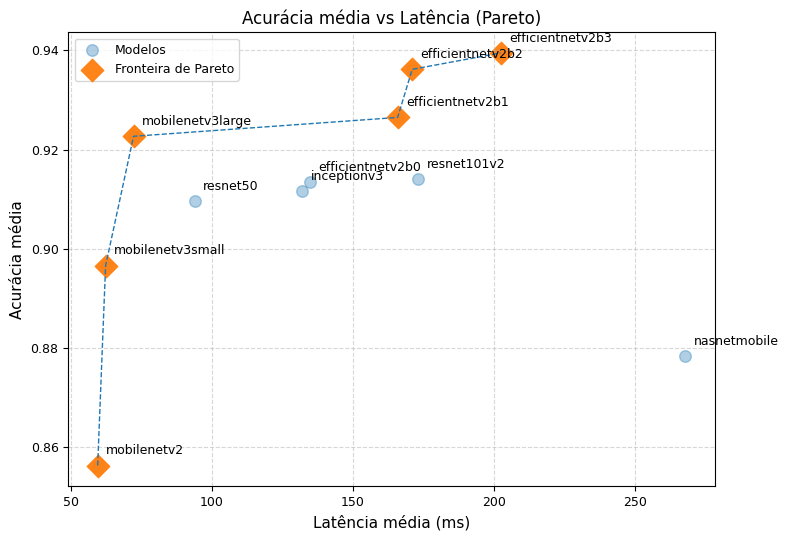

In [29]:
plot_metric_vs_accuracy_pareto(
    summary,
    x_col="[Real] Latência Média (ms)",
    x_mode="min",
    x_label="Latência média (ms)",
    title="Acurácia média vs Latência (Pareto)",
    save_path="acc_vs_latency_pareto.png"
)


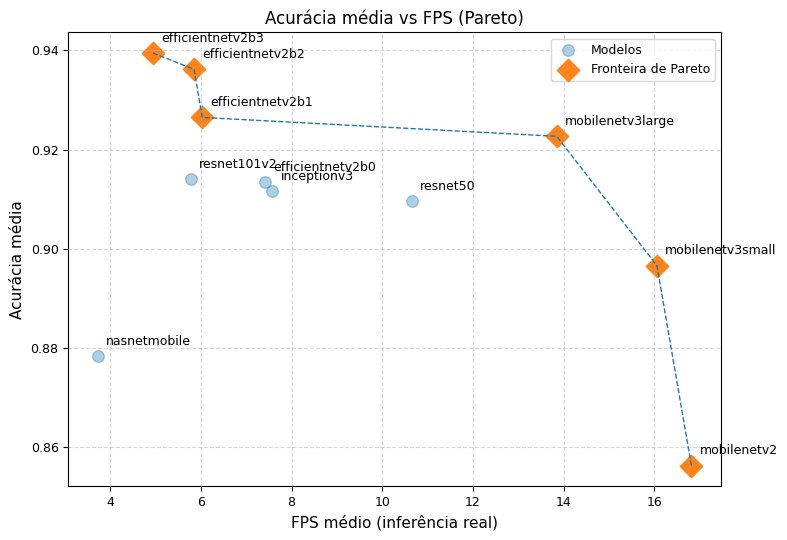

In [31]:
plot_metric_vs_accuracy_pareto(
    summary,
    x_col="[Real] FPS Média",
    x_mode="max",
    x_label="FPS médio (inferência real)",
    title="Acurácia média vs FPS (Pareto)",
    save_path="acc_vs_fps_pareto.png"
)


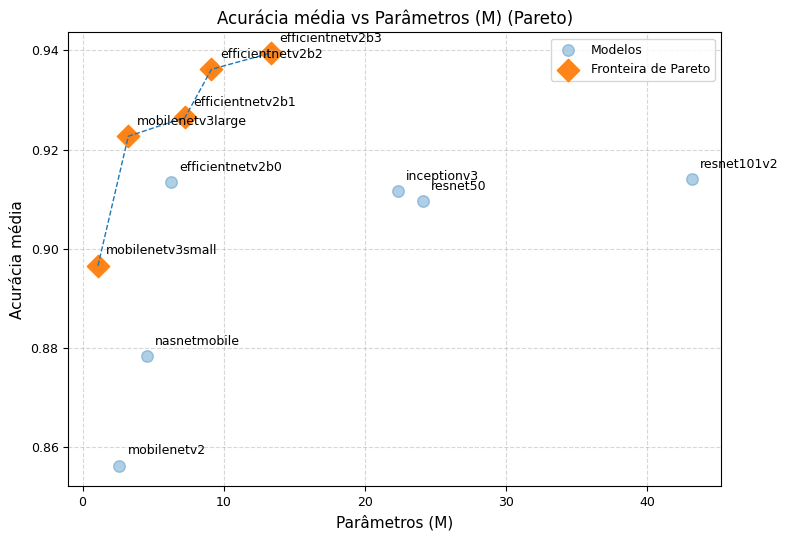

In [ ]:
plot_metric_vs_accuracy_pareto(
    summary,
    x_col="Parâmetros (M)",
    x_mode="min",
    x_label="Parâmetros (M)",
    title="Acurácia média vs Parâmetros (Pareto)",
    save_path="acc_vs_params_pareto.png"
)
